# Audit Notebook IHSG: Klaim Akurasi 99%

Notebook ini mengaudit kebocoran informasi ketika *scaler* di-*fit* pada
seluruh data sebelum pemisahan. Program membandingkan dua jalur memakai
fitur, model, target, dan tanggal uji yang sama:

1. **Jalur bocor**, dibuat sengaja untuk kebutuhan audit.
2. **Jalur terkoreksi**, yaitu *scaler* hanya di-*fit* pada data latih.

**Pertanyaan audit**

- Baris kode mana yang menyebabkan kebocoran?
- Informasi apa yang terpapar?
- Berapa selisih akurasi, *balanced accuracy*, F1, dan ROC-AUC?
- Apakah klaim 99% dapat dijelaskan hanya oleh kesalahan *scaling*?
- Apakah model tetap masuk akal setelah biaya transaksi diperhitungkan?

**Target penelitian**

Fitur yang selesai dihitung setelah penutupan hari ke-\(t\) dipakai
untuk memprediksi arah *return* pembukaan-ke-penutupan hari
ke-\(t+1\). Skema ini memberi *execution lag* yang jelas.

> Notebook ini dipakai untuk pembelajaran audit model. Hasilnya bukan
> rekomendasi investasi.

## A. Algoritma Program

1. Memuat data OHLCV IHSG dari CSV Kaggle atau ticker `^JKSE`.
2. Menstandarkan tanggal dan nama kolom.
3. Memeriksa duplikasi, nilai hilang, harga tidak valid, dan relasi OHLC.
4. Membentuk indikator teknikal hanya dari data masa lalu dan hari
   pengamatan.
5. Membentuk target arah *return* hari berikutnya beserta tanggal target.
6. Membagi data menjadi 70% latih, 15% validasi, dan 15% uji secara
   kronologis.
7. Menghapus satu observasi di batas periode jika tanggal target melewati
   batas pembagian.
8. Menjalankan jalur bocor melalui `scaler.fit_transform(X_all)`.
9. Menjalankan jalur benar melalui `scaler.fit(X_train)`, lalu
   `transform` untuk latih, validasi, dan uji.
10. Memilih ambang klasifikasi hanya dari data validasi.
11. Membandingkan metrik kedua jalur pada data uji yang sama.
12. Menjalankan validasi *rolling forward* pada jalur terkoreksi.
13. Menguji logika tanggal, fitur, target, *scaler*, dan pembagian.
14. Menyusun tabel audit berisi temuan, bukti, risiko, koreksi, dan
    status verifikasi.
15. Menyimpan seluruh keluaran ke `/kaggle/working/ihsg_leakage_audit`.

In [20]:
# OUTPUT TAHAP A: peta algoritma
import pandas as pd
from IPython.display import display

algorithm_map = pd.DataFrame(
    [
        (1, "Akuisisi", "CSV Kaggle atau ^JKSE", "OHLCV"),
        (2, "Audit data", "Tanggal, NaN, duplikasi, OHLC", "Tabel kualitas"),
        (3, "Fitur dan target", "Indikator kausal dan target t+1", "Dataset model"),
        (4, "Split waktu", "70/15/15 dan purge batas", "Train, validation, test"),
        (5, "Eksperimen bocor", "Fit scaler pada seluruh data", "Metrik pembanding"),
        (6, "Koreksi", "Fit scaler hanya pada train", "Metrik valid"),
        (7, "Validasi", "Rolling forward", "Stabilitas antarfold"),
        (8, "Audit akhir", "Tes otomatis dan tabel temuan", "Status verifikasi"),
    ],
    columns=["Tahap", "Proses", "Aktivitas", "Keluaran"],
)
display(algorithm_map)

,Tahap,Proses,Aktivitas,Keluaran
0,1,Akuisisi,CSV Kaggle atau ^JKSE,OHLCV
1,2,Audit data,"Tanggal, NaN, duplikasi, OHLC",Tabel kualitas
2,3,Fitur dan target,Indikator kausal dan target t+1,Dataset model
3,4,Split waktu,70/15/15 dan purge batas,"Train, validation, test"
4,5,Eksperimen bocor,Fit scaler pada seluruh data,Metrik pembanding
5,6,Koreksi,Fit scaler hanya pada train,Metrik valid
6,7,Validasi,Rolling forward,Stabilitas antarfold
7,8,Audit akhir,Tes otomatis dan tabel temuan,Status verifikasi


## B. Pseudocode Program

```text
MULAI
  MUAT data OHLCV IHSG
  VALIDASI tanggal, nilai hilang, duplikasi, dan relasi OHLC
  HITUNG fitur hari t tanpa shift negatif
  BENTUK target = arah return Open(t+1) ke Close(t+1)
  SIMPAN TargetDate = tanggal t+1

  TENTUKAN batas 70% train, 15% validation, 15% test
  HAPUS sampel batas jika TargetDate melewati periode berikutnya

  # Jalur bocor untuk audit
  X_ALL_SCALED = FIT_TRANSFORM scaler memakai seluruh data
  FIT model pada train
  PILIH threshold pada validation
  EVALUASI test

  # Jalur terkoreksi
  FIT scaler hanya memakai X_train
  TRANSFORM X_train, X_validation, dan X_test dengan scaler train
  FIT model pada train
  PILIH threshold pada validation
  EVALUASI test

  HITUNG selisih metrik = metrik_benar - metrik_bocor
  JALANKAN rolling-forward validation pada jalur benar
  JALANKAN tes otomatis integritas
  SUSUN tabel audit
  SIMPAN tabel, gambar, prediksi, dan kesimpulan
SELESAI
```

Jika skor turun setelah koreksi, penurunan itu bukan kegagalan. Nilai
baru lebih dekat dengan kondisi penggunaan nyata. Jika skor tetap 99%,
audit harus dilanjutkan karena *scaling leakage* biasanya bukan satu-satunya
penyebab skor ekstrem.

In [21]:
# OUTPUT TAHAP B: kontrol yang diterjemahkan dari pseudocode
pseudocode_controls = pd.DataFrame(
    {
        "Kontrol": [
            "Urutan waktu",
            "Kausalitas fitur",
            "Tanggal target",
            "Fit scaler",
            "Pemilihan threshold",
            "Data uji",
        ],
        "Aturan": [
            "Tanggal meningkat tanpa random shuffle",
            "Fitur hari t hanya memakai informasi sampai t",
            "TargetDate harus lebih besar dari FeatureDate",
            "Statistik hanya berasal dari train aktif",
            "Threshold hanya dipilih pada validation",
            "Test dipakai satu kali setelah keputusan dikunci",
        ],
        "Risiko yang Dicegah": [
            "Future-to-past contamination",
            "Look-ahead bias",
            "Off-by-one error",
            "Scaling leakage",
            "Test-set tuning",
            "Metrik terlalu optimistis",
        ],
    }
)
display(pseudocode_controls)

,Kontrol,Aturan,Risiko yang Dicegah
0,Urutan waktu,Tanggal meningkat tanpa random shuffle,Future-to-past contamination
1,Kausalitas fitur,Fitur hari t hanya memakai informasi sampai t,Look-ahead bias
2,Tanggal target,TargetDate harus lebih besar dari FeatureDate,Off-by-one error
3,Fit scaler,Statistik hanya berasal dari train aktif,Scaling leakage
4,Pemilihan threshold,Threshold hanya dipilih pada validation,Test-set tuning
5,Data uji,Test dipakai satu kali setelah keputusan dikunci,Metrik terlalu optimistis


In [22]:
# TAHAP 1: lingkungan, pustaka, dan parameter
import os
import sys
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
TICKER = "^JKSE"
START_DATE = "2010-01-01"
END_DATE = None
CSV_PATH = None  # Contoh: "/kaggle/input/ihsg-data/ihsg.csv"
TRANSACTION_COST_BPS = 10
OUTPUT_DIR = Path("/kaggle/working/ihsg_leakage_audit")
if not Path("/kaggle/working").exists():
    OUTPUT_DIR = Path.cwd() / "ihsg_leakage_audit"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TEST_MODE = os.getenv("IHSG_NOTEBOOK_TEST", "0") == "1"
COLORS = {
    "Train": "#2563EB",
    "Validation": "#F59E0B",
    "Test": "#DC2626",
    "Bocor": "#E11D48",
    "Terkoreksi": "#059669",
    "Netral": "#475569",
}

environment_table = pd.DataFrame(
    {
        "Komponen": ["Python", "NumPy", "Pandas", "Scikit-learn", "Mode uji lokal"],
        "Versi atau Nilai": [
            sys.version.split()[0],
            np.__version__,
            pd.__version__,
            __import__("sklearn").__version__,
            TEST_MODE,
        ],
        "Status": ["Siap"] * 5,
    }
)
print("OUTPUT TAHAP 1: lingkungan eksekusi")
display(environment_table)

OUTPUT TAHAP 1: lingkungan eksekusi


,Komponen,Versi atau Nilai,Status
0,Python,3.12.13,Siap
1,NumPy,2.0.2,Siap
2,Pandas,2.3.3,Siap
3,Scikit-learn,1.6.1,Siap
4,Mode uji lokal,False,Siap


OUTPUT TAHAP 2: ringkasan data


,Indikator,Nilai
0,Sumber,Yahoo Finance: ^JKSE
1,Tanggal awal,2010-01-04
2,Tanggal akhir,2026-07-30
3,Jumlah observasi,"4,019"
4,Valid untuk kesimpulan IHSG,True


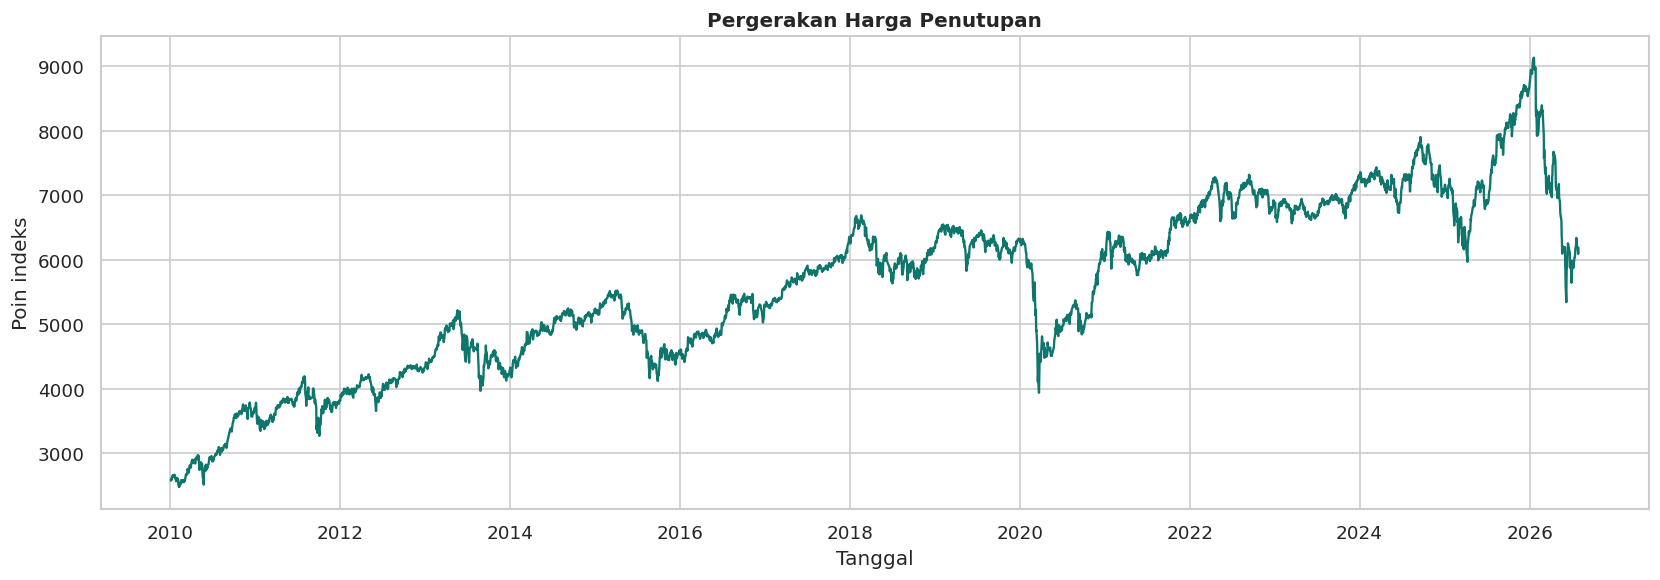

In [23]:
# TAHAP 2: fungsi pemuatan dan standardisasi data
def standardize_ohlcv(raw):
    df = raw.copy()
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [
            str(col[0]) if str(col[0]) not in ("", "None") else str(col[-1])
            for col in df.columns
        ]
    df.columns = [str(c).strip() for c in df.columns]

    date_candidates = [c for c in df.columns if c.lower() in {"date", "datetime", "tanggal", "time"}]
    if date_candidates:
        df[date_candidates[0]] = pd.to_datetime(df[date_candidates[0]], errors="coerce")
        df = df.set_index(date_candidates[0])
    else:
        df.index = pd.to_datetime(df.index, errors="coerce")

    alias_map = {
        "Open": ["open", "opening", "harga pembukaan"],
        "High": ["high", "tertinggi"],
        "Low": ["low", "terendah"],
        "Close": ["close", "adj close", "adjusted close", "penutupan"],
        "Volume": ["volume", "vol"],
    }
    normalized = {str(c).lower().strip(): c for c in df.columns}
    rename = {}
    for target, aliases in alias_map.items():
        for alias in aliases:
            if alias in normalized:
                rename[normalized[alias]] = target
                break
    df = df.rename(columns=rename)

    required_price = ["Open", "High", "Low", "Close"]
    missing = [c for c in required_price if c not in df.columns]
    if missing:
        raise ValueError(f"Kolom harga belum lengkap: {missing}")
    if "Volume" not in df.columns:
        df["Volume"] = 0.0

    df = df[["Open", "High", "Low", "Close", "Volume"]].apply(
        pd.to_numeric, errors="coerce"
    )
    df = df[~df.index.isna()].sort_index()
    df = df[~df.index.duplicated(keep="last")]
    df = df.dropna(subset=required_price)
    df["Volume"] = df["Volume"].fillna(0.0)
    return df


def synthetic_market(seed=42, periods=3600):
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range("2010-01-04", periods=periods)
    regime = np.where(np.arange(periods) < periods * 0.70, 0.008, 0.015)
    shock = rng.normal(0.00025, regime)
    close = 2500 * np.exp(np.cumsum(shock))
    overnight = rng.normal(0.00005, 0.0035, periods)
    open_ = np.r_[close[0], close[:-1]] * np.exp(overnight)
    spread = np.abs(rng.normal(0.006, 0.003, periods))
    high = np.maximum(open_, close) * (1 + spread)
    low = np.minimum(open_, close) * np.maximum(0.85, 1 - spread)
    volume = rng.lognormal(18, 0.45, periods)
    return pd.DataFrame(
        {"Open": open_, "High": high, "Low": low, "Close": close, "Volume": volume},
        index=dates,
    )


def find_kaggle_csv():
    candidates = []
    if CSV_PATH:
        candidates.append(CSV_PATH)
    candidates.extend(glob.glob("/kaggle/input/**/*.csv", recursive=True))
    for path in candidates:
        try:
            probe = pd.read_csv(path, nrows=10)
            cols = {str(c).lower().strip() for c in probe.columns}
            has_date = bool(cols & {"date", "datetime", "tanggal", "time"})
            has_prices = {"open", "high", "low", "close"}.issubset(cols)
            if has_date and has_prices:
                return path
        except Exception:
            continue
    return None


def load_ihsg():
    if TEST_MODE:
        return standardize_ohlcv(synthetic_market()), "SYNTHETIC_TEST_ONLY"

    csv_file = find_kaggle_csv()
    if csv_file:
        return standardize_ohlcv(pd.read_csv(csv_file)), f"CSV: {csv_file}"

    try:
        import yfinance as yf
    except ImportError:
        try:
            import subprocess
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "yfinance"])
            import yfinance as yf
        except Exception:
            yf = None

    if yf is not None:
        try:
            downloaded = yf.download(
                TICKER,
                start=START_DATE,
                end=END_DATE,
                auto_adjust=False,
                progress=False,
            )
            if downloaded is not None and not downloaded.empty:
                return standardize_ohlcv(downloaded), f"Yahoo Finance: {TICKER}"
        except Exception as exc:
            print("Unduhan gagal:", type(exc).__name__)

    fallback = standardize_ohlcv(synthetic_market())
    return fallback, "SYNTHETIC_FALLBACK_NOT_FOR_CONCLUSION"


ihsg, DATA_SOURCE = load_ihsg()
source_valid_for_research = not DATA_SOURCE.startswith("SYNTHETIC")

data_summary = pd.DataFrame(
    {
        "Indikator": [
            "Sumber",
            "Tanggal awal",
            "Tanggal akhir",
            "Jumlah observasi",
            "Valid untuk kesimpulan IHSG",
        ],
        "Nilai": [
            DATA_SOURCE,
            ihsg.index.min().date(),
            ihsg.index.max().date(),
            f"{len(ihsg):,}",
            source_valid_for_research,
        ],
    }
)
print("OUTPUT TAHAP 2: ringkasan data")
display(data_summary)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ihsg.index, ihsg["Close"], color="#0F766E", linewidth=1.4)
ax.set_title("Pergerakan Harga Penutupan")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Poin indeks")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "01_harga_penutupan.png", dpi=180, bbox_inches="tight")
plt.show()

OUTPUT TAHAP 3: laporan kualitas data


,Pemeriksaan,Jumlah Temuan,Kriteria,Status
0,Tanggal duplikat,0,Harus 0,LULUS
1,Tanggal tidak berurutan,0,Harus 0,LULUS
2,Nilai harga kosong,0,Harus 0,LULUS
3,Harga tidak positif,0,Harus 0,LULUS
4,High di bawah Open/Close,0,Harus 0,LULUS
5,Low di atas Open/Close,0,Harus 0,LULUS
6,Volume nol,9,Boleh terjadi pada indeks,LULUS


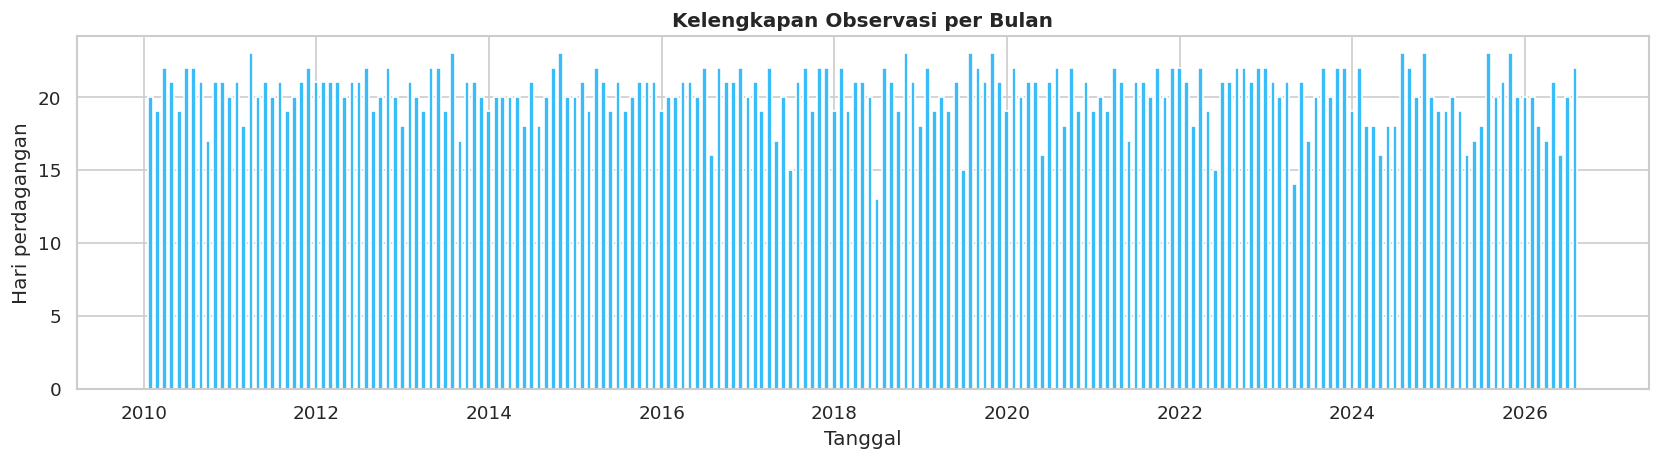

In [24]:
# TAHAP 3: audit kualitas data mentah
quality_checks = [
    ("Tanggal duplikat", int(ihsg.index.duplicated().sum()), "Harus 0"),
    ("Tanggal tidak berurutan", int(not ihsg.index.is_monotonic_increasing), "Harus 0"),
    ("Nilai harga kosong", int(ihsg[["Open", "High", "Low", "Close"]].isna().sum().sum()), "Harus 0"),
    ("Harga tidak positif", int((ihsg[["Open", "High", "Low", "Close"]] <= 0).sum().sum()), "Harus 0"),
    ("High di bawah Open/Close", int((ihsg["High"] < ihsg[["Open", "Close"]].max(axis=1)).sum()), "Harus 0"),
    ("Low di atas Open/Close", int((ihsg["Low"] > ihsg[["Open", "Close"]].min(axis=1)).sum()), "Harus 0"),
    ("Volume nol", int((ihsg["Volume"] == 0).sum()), "Boleh terjadi pada indeks"),
]
quality_report = pd.DataFrame(
    quality_checks, columns=["Pemeriksaan", "Jumlah Temuan", "Kriteria"]
)
quality_report["Status"] = np.where(
    (quality_report["Pemeriksaan"] == "Volume nol")
    | (quality_report["Jumlah Temuan"] == 0),
    "LULUS",
    "PERIKSA",
)
print("OUTPUT TAHAP 3: laporan kualitas data")
display(quality_report)

monthly_obs = ihsg["Close"].resample("ME").count()
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(monthly_obs.index, monthly_obs.values, width=20, color="#38BDF8")
ax.set_title("Kelengkapan Observasi per Bulan")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Hari perdagangan")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "02_kelengkapan_bulanan.png", dpi=180, bbox_inches="tight")
plt.show()

OUTPUT TAHAP 4: kamus fitur dan contoh data


,Fitur,Makna,Rumus Ringkas
0,"ret_1, ret_2, ret_5",Momentum harga,Log-return historis
1,"sma_5_ratio, sma_20_ratio",Posisi terhadap tren,Harga / SMA - 1
2,"ema_12_ratio, ema_26_ratio",Tren berbobot,Harga / EMA - 1
3,"volatility_5, volatility_20",Risiko historis,Simpangan baku return
4,rsi_14,Momentum relatif,RSI dibagi 100
5,macd_ratio,Selisih tren,(EMA12 - EMA26) / harga
6,"range_ratio, close_location",Rentang harian,"Relasi High, Low, dan Close"
7,gap_ratio,Perubahan semalam,Open(t) / Close(t-1) - 1
8,"volume_change, volume_z20",Dinamika volume,Perubahan dan z-score historis


,ret_1,ret_2,ret_5,sma_5_ratio,sma_20_ratio,ema_12_ratio,ema_26_ratio,volatility_5,volatility_20,rsi_14,macd_ratio,range_ratio,close_location,gap_ratio,volume_change,volume_z20,Target,TargetDate
Date,,,,,,,,,,,,,,,,,,
2026-07-23,-0.0030,-0.0039,0.0333,0.0057,0.0533,0.0259,0.0347,0.0085,0.0137,0.8073,0.0083,0.0234,0.0587,0.0019,0.2999,2.4521,0,2026-07-24
2026-07-24,-0.0190,-0.0220,0.0034,-0.0139,0.0309,0.0055,0.0141,0.0137,0.0138,0.6766,0.0084,0.0177,0.3408,-0.0077,-0.5471,0.9719,0,2026-07-27
2026-07-27,-0.0017,-0.0207,-0.0074,-0.0141,0.0260,0.0032,0.0114,0.0128,0.0134,0.6358,0.0081,0.0121,0.5524,-0.0017,-0.3112,0.1199,0,2026-07-28
2026-07-28,-0.0090,-0.0107,-0.0336,-0.0164,0.0128,-0.0049,0.0022,0.0076,0.0111,0.6902,0.0071,0.0112,0.0000,-0.0017,-0.2001,-0.4329,0,2026-07-29
2026-07-29,-0.0064,-0.0154,-0.0391,-0.0150,0.0030,-0.0095,-0.0039,0.0069,0.0113,0.6323,0.0057,0.0238,0.4278,0.0017,0.3764,0.5119,1,2026-07-30


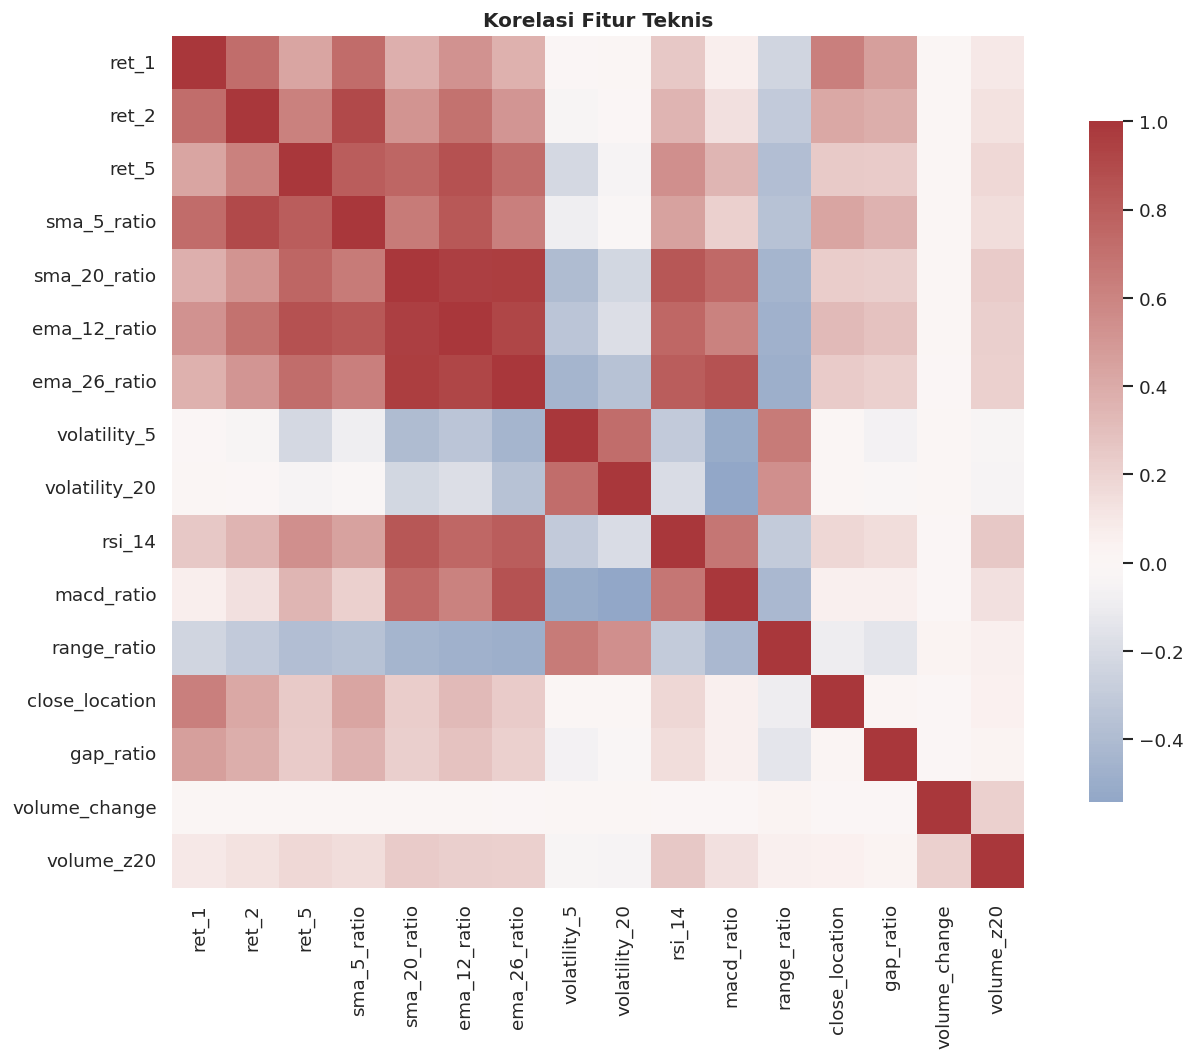

In [25]:
# TAHAP 4: pembentukan fitur dan target yang kausal
def rsi(series, window=14):
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(window).mean()
    loss = (-delta.clip(upper=0)).rolling(window).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def make_model_data(df):
    out = pd.DataFrame(index=df.index)
    close = df["Close"]
    open_ = df["Open"]
    log_close = np.log(close)
    ret = log_close.diff()

    out["ret_1"] = ret
    out["ret_2"] = log_close.diff(2)
    out["ret_5"] = log_close.diff(5)
    out["sma_5_ratio"] = close / close.rolling(5).mean() - 1
    out["sma_20_ratio"] = close / close.rolling(20).mean() - 1
    out["ema_12_ratio"] = close / close.ewm(span=12, adjust=False).mean() - 1
    out["ema_26_ratio"] = close / close.ewm(span=26, adjust=False).mean() - 1
    out["volatility_5"] = ret.rolling(5).std()
    out["volatility_20"] = ret.rolling(20).std()
    out["rsi_14"] = rsi(close, 14) / 100.0
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    out["macd_ratio"] = (ema12 - ema26) / close
    out["range_ratio"] = (df["High"] - df["Low"]) / close
    out["close_location"] = (close - df["Low"]) / (df["High"] - df["Low"]).replace(0, np.nan)
    out["gap_ratio"] = open_ / close.shift(1) - 1
    out["volume_change"] = np.log1p(df["Volume"]).diff()
    vol_log = np.log1p(df["Volume"])
    out["volume_z20"] = (
        (vol_log - vol_log.rolling(20).mean())
        / vol_log.rolling(20).std().replace(0, np.nan)
    )

    next_intraday_return = close.shift(-1) / open_.shift(-1) - 1
    target = pd.Series(np.nan, index=df.index, dtype=float)
    valid_target = next_intraday_return.notna()
    target.loc[valid_target] = (next_intraday_return.loc[valid_target] > 0).astype(int)
    out["NextReturn"] = next_intraday_return
    out["Target"] = target
    out["TargetDate"] = pd.Series(df.index, index=df.index).shift(-1)
    return out


model_data = make_model_data(ihsg)
FEATURE_COLUMNS = [
    "ret_1", "ret_2", "ret_5", "sma_5_ratio", "sma_20_ratio",
    "ema_12_ratio", "ema_26_ratio", "volatility_5", "volatility_20",
    "rsi_14", "macd_ratio", "range_ratio", "close_location",
    "gap_ratio", "volume_change", "volume_z20",
]
model_data = model_data.dropna(
    subset=FEATURE_COLUMNS + ["Target", "TargetDate", "NextReturn"]
).copy()
model_data["Target"] = model_data["Target"].astype(int)

feature_dictionary = pd.DataFrame(
    [
        ("ret_1, ret_2, ret_5", "Momentum harga", "Log-return historis"),
        ("sma_5_ratio, sma_20_ratio", "Posisi terhadap tren", "Harga / SMA - 1"),
        ("ema_12_ratio, ema_26_ratio", "Tren berbobot", "Harga / EMA - 1"),
        ("volatility_5, volatility_20", "Risiko historis", "Simpangan baku return"),
        ("rsi_14", "Momentum relatif", "RSI dibagi 100"),
        ("macd_ratio", "Selisih tren", "(EMA12 - EMA26) / harga"),
        ("range_ratio, close_location", "Rentang harian", "Relasi High, Low, dan Close"),
        ("gap_ratio", "Perubahan semalam", "Open(t) / Close(t-1) - 1"),
        ("volume_change, volume_z20", "Dinamika volume", "Perubahan dan z-score historis"),
    ],
    columns=["Fitur", "Makna", "Rumus Ringkas"],
)
print("OUTPUT TAHAP 4: kamus fitur dan contoh data")
display(feature_dictionary)
display(model_data[FEATURE_COLUMNS + ["Target", "TargetDate"]].tail(5))

corr = model_data[FEATURE_COLUMNS].corr()
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, cmap="vlag", center=0, square=True, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Korelasi Fitur Teknis")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "03_korelasi_fitur.png", dpi=180, bbox_inches="tight")
plt.show()

OUTPUT TAHAP 5: sampel penyelarasan waktu


,FeatureDate,gap_ratio,ret_1,NextReturn,Target,TargetDate,UrutanValid
Date,,,,,,,
2010-02-01,2010-02-01,-0.0001,-0.0089,-0.0031,0,2010-02-02,True
2010-02-02,2010-02-02,0.0003,-0.0028,0.0093,1,2010-02-03,True
2010-02-03,2010-02-03,0.0002,0.0094,-0.0044,0,2010-02-04,True
2018-04-03,2018-04-03,-0.0045,-0.0019,-0.0134,0,2018-04-04,True
2026-07-27,2026-07-27,-0.0017,-0.0017,-0.0072,0,2026-07-28,True
2026-07-28,2026-07-28,-0.0017,-0.0090,-0.0081,0,2026-07-29,True
2026-07-29,2026-07-29,0.0017,-0.0064,0.0125,1,2026-07-30,True


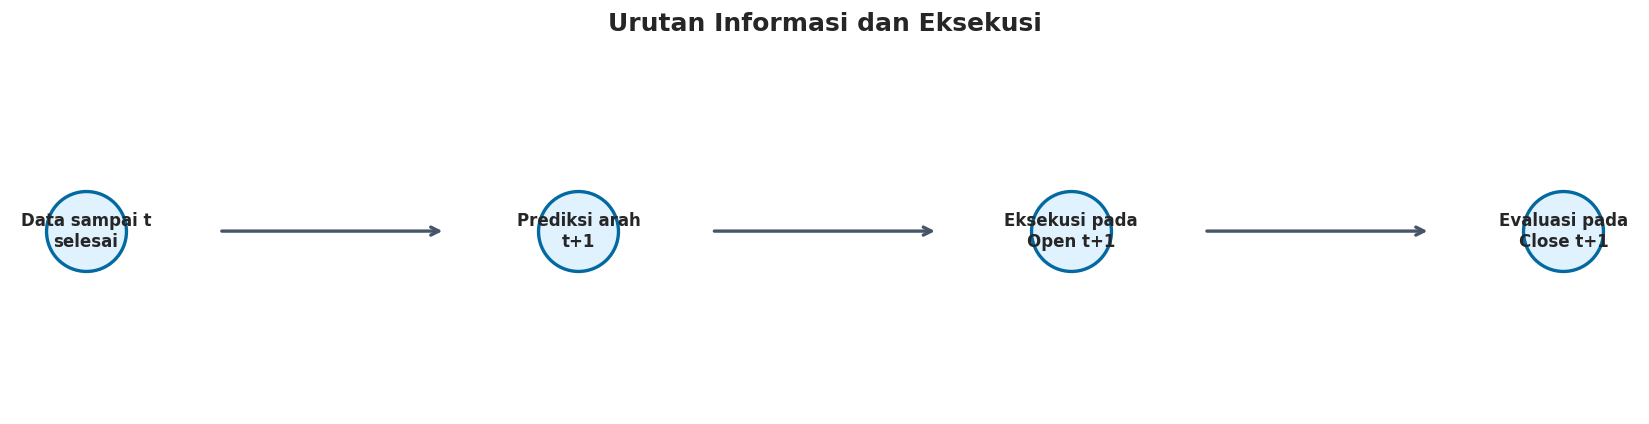

In [26]:
# TAHAP 5: pemeriksaan penyelarasan fitur, target, dan execution lag
alignment_view = model_data[
    ["gap_ratio", "ret_1", "NextReturn", "Target", "TargetDate"]
].iloc[[0, 1, 2, len(model_data)//2, -3, -2, -1]].copy()
alignment_view.insert(0, "FeatureDate", alignment_view.index)
alignment_view["UrutanValid"] = alignment_view["TargetDate"] > alignment_view["FeatureDate"]

print("OUTPUT TAHAP 5: sampel penyelarasan waktu")
display(alignment_view)

fig, ax = plt.subplots(figsize=(14, 3.7))
ax.axis("off")
nodes = [
    (0.08, "Data sampai t\nselesai"),
    (0.34, "Prediksi arah\nt+1"),
    (0.60, "Eksekusi pada\nOpen t+1"),
    (0.86, "Evaluasi pada\nClose t+1"),
]
for x, label in nodes:
    ax.scatter([x], [0.55], s=2300, color="#E0F2FE", edgecolor="#0369A1", linewidth=2)
    ax.text(x, 0.55, label, ha="center", va="center", fontsize=10, weight="bold")
for left, right in zip(nodes[:-1], nodes[1:]):
    ax.annotate("", xy=(right[0]-0.07, 0.55), xytext=(left[0]+0.07, 0.55),
                arrowprops={"arrowstyle": "->", "color": "#475569", "lw": 2})
ax.set_title("Urutan Informasi dan Eksekusi", fontsize=15, weight="bold", pad=12)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "04_alignment_timeline.png", dpi=180, bbox_inches="tight")
plt.show()

OUTPUT TAHAP 6: pembagian kronologis


,Kelompok,Tanggal Awal,Tanggal Akhir,Jumlah,Proporsi Target 1,Proporsi
0,Train,2010-02-01,2021-07-28,2794,0.5251,0.7001
1,Validation,2021-07-30,2024-01-09,598,0.5284,0.1498
2,Test,2024-01-11,2026-07-29,599,0.4508,0.1501


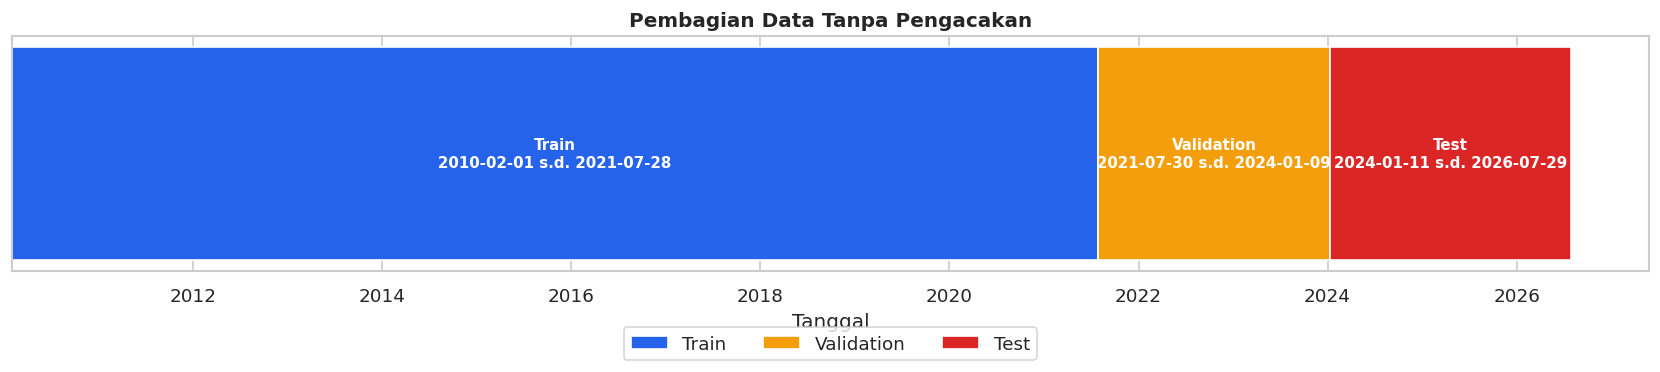

In [27]:
# TAHAP 6: split kronologis 70/15/15 dan purge pada batas
n = len(model_data)
val_start = model_data.index[int(n * 0.70)]
test_start = model_data.index[int(n * 0.85)]

train_df = model_data[
    (model_data.index < val_start)
    & (model_data["TargetDate"] < val_start)
].copy()
valid_df = model_data[
    (model_data.index >= val_start)
    & (model_data.index < test_start)
    & (model_data["TargetDate"] < test_start)
].copy()
test_df = model_data[model_data.index >= test_start].copy()

X_train, y_train = train_df[FEATURE_COLUMNS], train_df["Target"]
X_valid, y_valid = valid_df[FEATURE_COLUMNS], valid_df["Target"]
X_test, y_test = test_df[FEATURE_COLUMNS], test_df["Target"]

split_summary = pd.DataFrame(
    [
        ("Train", train_df.index.min(), train_df.index.max(), len(train_df), y_train.mean()),
        ("Validation", valid_df.index.min(), valid_df.index.max(), len(valid_df), y_valid.mean()),
        ("Test", test_df.index.min(), test_df.index.max(), len(test_df), y_test.mean()),
    ],
    columns=["Kelompok", "Tanggal Awal", "Tanggal Akhir", "Jumlah", "Proporsi Target 1"],
)
split_summary["Proporsi"] = split_summary["Jumlah"] / split_summary["Jumlah"].sum()
print("OUTPUT TAHAP 6: pembagian kronologis")
display(split_summary)

fig, ax = plt.subplots(figsize=(14, 3.4))
spans = [
    (train_df.index.min(), train_df.index.max(), "Train", COLORS["Train"]),
    (valid_df.index.min(), valid_df.index.max(), "Validation", COLORS["Validation"]),
    (test_df.index.min(), test_df.index.max(), "Test", COLORS["Test"]),
]
for i, (start, end, label, color) in enumerate(spans):
    ax.barh(0, (end-start).days, left=start, height=0.45, color=color, label=label)
    ax.text(start + (end-start)/2, 0, f"{label}\n{start.date()} s.d. {end.date()}",
            ha="center", va="center", color="white", fontsize=9, weight="bold")
ax.set_yticks([])
ax.set_xlabel("Tanggal")
ax.set_title("Pembagian Data Tanpa Pengacakan")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.20))
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "05_split_kronologis.png", dpi=180, bbox_inches="tight")
plt.show()

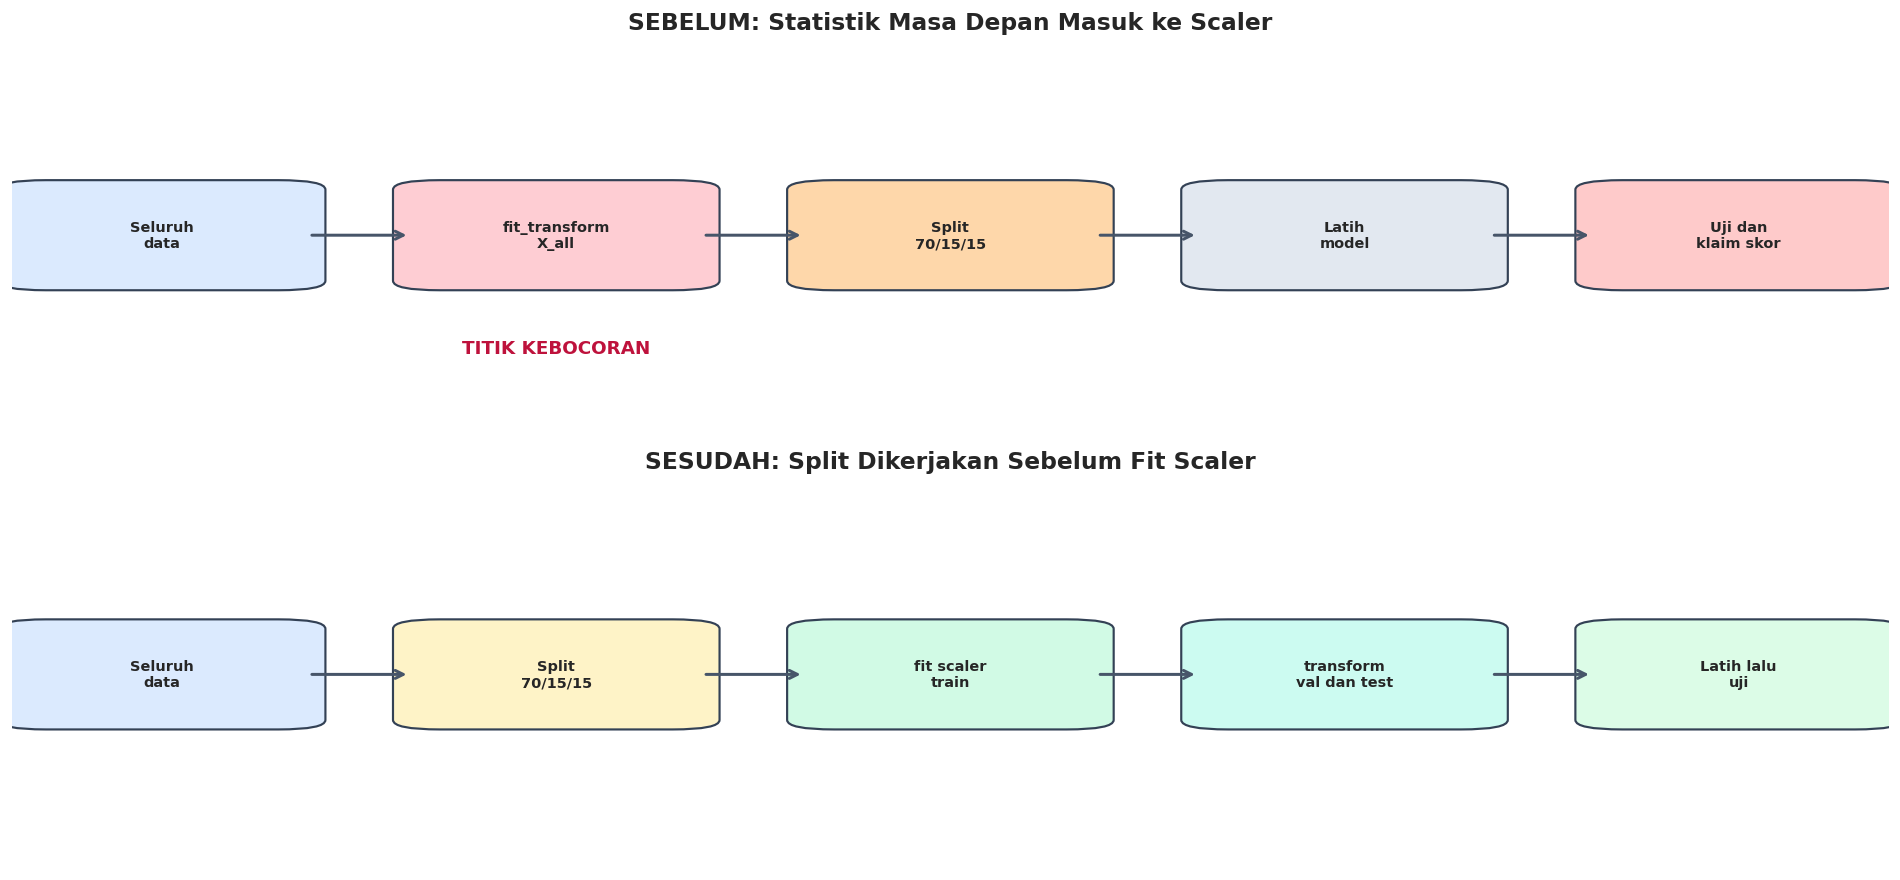

OUTPUT TAHAP 7: lokasi kode bocor


,Versi,Baris Inti,Informasi yang Dipelajari Scaler
0,Bocor,X_all_scaled = scaler.fit_transform(X_all),"Rata-rata dan simpangan baku train, validation, serta test"
1,Terkoreksi,scaler.fit(X_train); scaler.transform(X_valid/X_test),Rata-rata dan simpangan baku train saja


In [28]:
# TAHAP 7: diagram alir sebelum dan sesudah koreksi
from matplotlib.patches import FancyBboxPatch

def draw_pipeline(ax, title, steps, colors):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.set_title(title, fontsize=14, weight="bold", pad=12)
    xs = np.linspace(0.08, 0.92, len(steps))
    for i, (x, label, color) in enumerate(zip(xs, steps, colors)):
        box = FancyBboxPatch(
            (x-0.072, 0.38), 0.144, 0.26,
            boxstyle="round,pad=0.015,rounding_size=0.025",
            facecolor=color, edgecolor="#334155", linewidth=1.3,
        )
        ax.add_patch(box)
        ax.text(x, 0.51, label, ha="center", va="center", fontsize=8.7, weight="bold")
        if i < len(steps)-1:
            ax.annotate("", xy=(xs[i+1]-0.078, 0.51), xytext=(x+0.078, 0.51),
                        arrowprops={"arrowstyle": "->", "lw": 1.8, "color": "#475569"})

fig, axes = plt.subplots(2, 1, figsize=(16, 7.5))
draw_pipeline(
    axes[0],
    "SEBELUM: Statistik Masa Depan Masuk ke Scaler",
    ["Seluruh\ndata", "fit_transform\nX_all", "Split\n70/15/15", "Latih\nmodel", "Uji dan\nklaim skor"],
    ["#DBEAFE", "#FECDD3", "#FED7AA", "#E2E8F0", "#FECACA"],
)
axes[0].text(0.29, 0.20, "TITIK KEBOCORAN", color="#BE123C", fontsize=11, weight="bold", ha="center")
draw_pipeline(
    axes[1],
    "SESUDAH: Split Dikerjakan Sebelum Fit Scaler",
    ["Seluruh\ndata", "Split\n70/15/15", "fit scaler\ntrain", "transform\nval dan test", "Latih lalu\nuji"],
    ["#DBEAFE", "#FEF3C7", "#D1FAE5", "#CCFBF1", "#DCFCE7"],
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "06_pipeline_sebelum_sesudah.png", dpi=200, bbox_inches="tight")
plt.show()

leakage_location = pd.DataFrame(
    {
        "Versi": ["Bocor", "Terkoreksi"],
        "Baris Inti": [
            "X_all_scaled = scaler.fit_transform(X_all)",
            "scaler.fit(X_train); scaler.transform(X_valid/X_test)",
        ],
        "Informasi yang Dipelajari Scaler": [
            "Rata-rata dan simpangan baku train, validation, serta test",
            "Rata-rata dan simpangan baku train saja",
        ],
    }
)
print("OUTPUT TAHAP 7: lokasi kode bocor")
display(leakage_location)

In [29]:
# TAHAP 8: fungsi eksperimen yang menjaga model tetap sama
def select_f1_threshold(y_true, scores):
    candidates = np.unique(np.quantile(scores, np.linspace(0.05, 0.95, 181)))
    records = []
    for threshold in candidates:
        pred = (scores >= threshold).astype(int)
        records.append((threshold, f1_score(y_true, pred, zero_division=0)))
    table = pd.DataFrame(records, columns=["Threshold", "F1"])
    best_f1 = table["F1"].max()
    best = table[table["F1"] == best_f1].copy()
    best["DistanceToZero"] = best["Threshold"].abs()
    return float(best.sort_values(["DistanceToZero", "Threshold"]).iloc[0]["Threshold"])


def calculate_metrics(y_true, scores, threshold, label):
    pred = (scores >= threshold).astype(int)
    return {
        "Pipeline": label,
        "Accuracy": accuracy_score(y_true, pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, scores),
        "Threshold Validation": threshold,
    }, pred


def run_branch(mode):
    model = SVC(
        C=1.0,
        kernel="rbf",
        gamma="scale",
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )
    scaler = StandardScaler()

    if mode == "leaky":
        # BARIS INI SENGAJA SALAH UNTUK EKSPERIMEN AUDIT.
        X_all = pd.concat([X_train, X_valid, X_test], axis=0)
        X_all_scaled = scaler.fit_transform(X_all)
        n_train = len(X_train)
        n_valid = len(X_valid)
        Xtr = X_all_scaled[:n_train]
        Xva = X_all_scaled[n_train:n_train+n_valid]
        Xte = X_all_scaled[n_train+n_valid:]
        label = "Bocor"
    elif mode == "clean":
        scaler.fit(X_train)
        Xtr = scaler.transform(X_train)
        Xva = scaler.transform(X_valid)
        Xte = scaler.transform(X_test)
        label = "Terkoreksi"
    else:
        raise ValueError("mode harus leaky atau clean")

    model.fit(Xtr, y_train)
    valid_scores = model.decision_function(Xva)
    threshold = select_f1_threshold(y_valid, valid_scores)
    test_scores = model.decision_function(Xte)
    metrics, test_pred = calculate_metrics(y_test, test_scores, threshold, label)
    return {
        "label": label,
        "scaler": scaler,
        "model": model,
        "threshold": threshold,
        "valid_scores": valid_scores,
        "test_scores": test_scores,
        "test_pred": test_pred,
        "metrics": metrics,
    }


leaky_result = run_branch("leaky")
clean_result = run_branch("clean")
stage8_table = pd.DataFrame(
    [
        {
            "Pipeline": leaky_result["label"],
            "Scaler Fit Rows": leaky_result["scaler"].n_samples_seen_,
            "Train Rows": len(X_train),
            "Validation Rows": len(X_valid),
            "Test Rows": len(X_test),
            "Threshold dari Validation": leaky_result["threshold"],
        },
        {
            "Pipeline": clean_result["label"],
            "Scaler Fit Rows": clean_result["scaler"].n_samples_seen_,
            "Train Rows": len(X_train),
            "Validation Rows": len(X_valid),
            "Test Rows": len(X_test),
            "Threshold dari Validation": clean_result["threshold"],
        },
    ]
)
print("OUTPUT TAHAP 8: bukti jumlah baris yang dipelajari scaler")
display(stage8_table)

OUTPUT TAHAP 8: bukti jumlah baris yang dipelajari scaler


,Pipeline,Scaler Fit Rows,Train Rows,Validation Rows,Test Rows,Threshold dari Validation
0,Bocor,3991,2794,598,599,-0.8287
1,Terkoreksi,2794,2794,598,599,-0.8923


OUTPUT TAHAP 9: selisih metrik pada test yang sama


Pipeline,Bocor,Terkoreksi,Selisih Terkoreksi - Bocor
Accuracy,0.4641,0.4691,0.0050
Balanced Accuracy,0.5025,0.5087,0.0062
Precision,0.4522,0.4556,0.0034
Recall,0.8926,0.9111,0.0185
F1,0.6002,0.6074,0.0072
ROC-AUC,0.5233,0.5240,0.0007


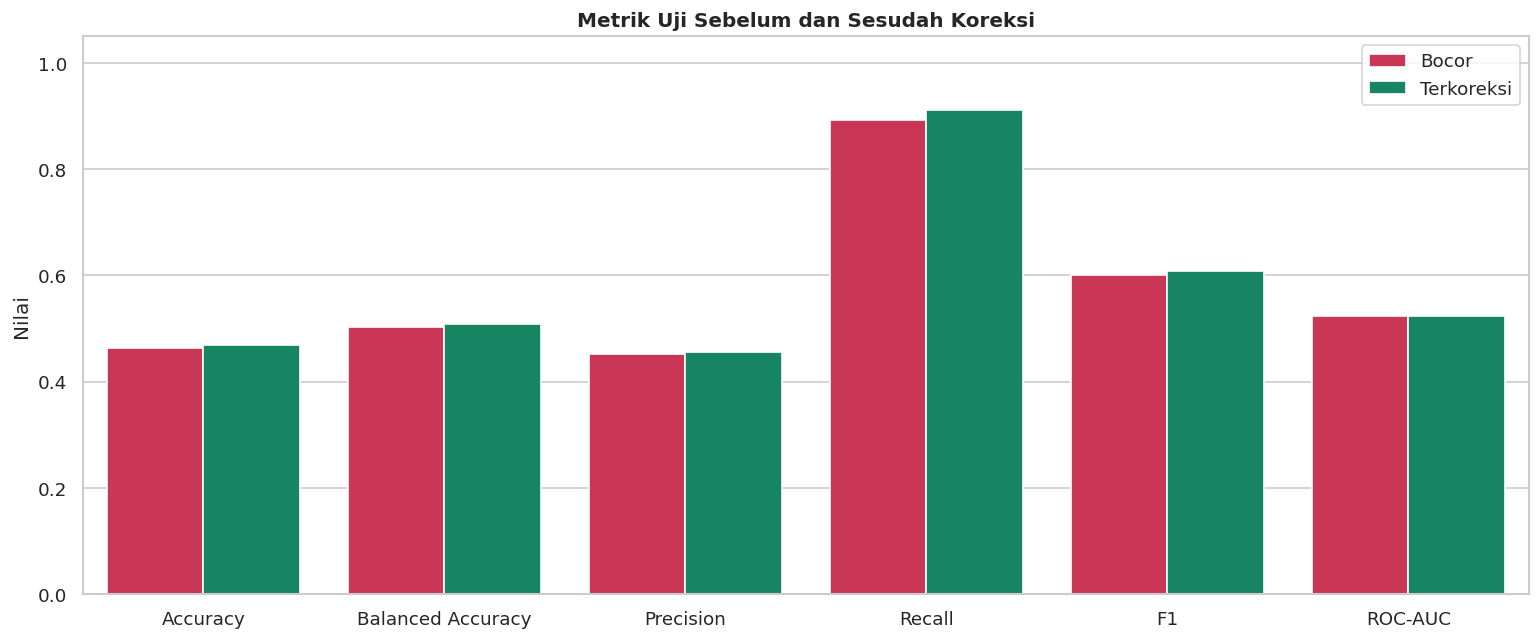

,Pemeriksaan,Nilai,Interpretasi
0,Akurasi jalur bocor,0.4641,Hanya pembanding audit
1,Akurasi jalur terkoreksi,0.4691,Estimasi yang sah
2,Perubahan absolut,0.0050,Negatif berarti skor turun setelah koreksi
3,Klaim 99% terulang,False,"Jika ya, lanjutkan audit target dan split"


In [30]:
# TAHAP 9: perbandingan metrik sebelum dan sesudah koreksi
metric_table = pd.DataFrame([leaky_result["metrics"], clean_result["metrics"]])
metric_names = ["Accuracy", "Balanced Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
comparison = metric_table.set_index("Pipeline")[metric_names].T
comparison["Selisih Terkoreksi - Bocor"] = (
    comparison["Terkoreksi"] - comparison["Bocor"]
)

print("OUTPUT TAHAP 9: selisih metrik pada test yang sama")
display(comparison.round(4))

plot_data = metric_table.melt(
    id_vars="Pipeline", value_vars=metric_names,
    var_name="Metrik", value_name="Nilai"
)
fig, ax = plt.subplots(figsize=(13, 5.5))
sns.barplot(
    data=plot_data, x="Metrik", y="Nilai", hue="Pipeline",
    palette={"Bocor": COLORS["Bocor"], "Terkoreksi": COLORS["Terkoreksi"]},
    ax=ax,
)
ax.set_ylim(0, 1.05)
ax.set_title("Metrik Uji Sebelum dan Sesudah Koreksi")
ax.set_ylabel("Nilai")
ax.set_xlabel("")
ax.legend(title="")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "07_perbandingan_metrik.png", dpi=200, bbox_inches="tight")
plt.show()

acc_leaky = float(metric_table.loc[metric_table["Pipeline"] == "Bocor", "Accuracy"].iloc[0])
acc_clean = float(metric_table.loc[metric_table["Pipeline"] == "Terkoreksi", "Accuracy"].iloc[0])
claim_analysis = pd.DataFrame(
    [
        ("Akurasi jalur bocor", acc_leaky, "Hanya pembanding audit"),
        ("Akurasi jalur terkoreksi", acc_clean, "Estimasi yang sah"),
        ("Perubahan absolut", acc_clean - acc_leaky, "Negatif berarti skor turun setelah koreksi"),
        ("Klaim 99% terulang", max(acc_leaky, acc_clean) >= 0.99, "Jika ya, lanjutkan audit target dan split"),
    ],
    columns=["Pemeriksaan", "Nilai", "Interpretasi"],
)
display(claim_analysis)

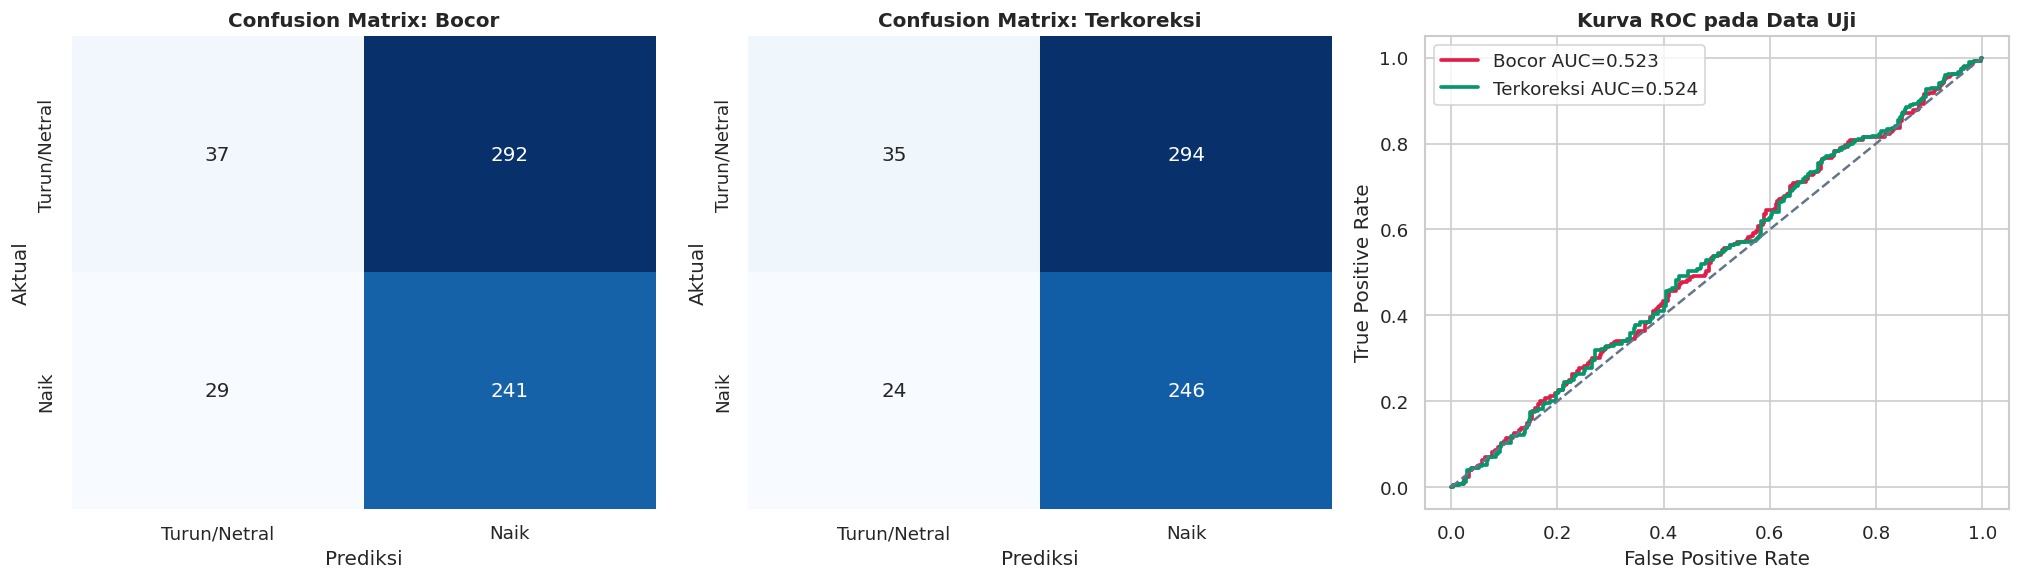

OUTPUT TAHAP 10: contoh prediksi uji


,Target Aktual,Skor Bocor,Prediksi Bocor,Skor Terkoreksi,Prediksi Terkoreksi,Return Aktual
Date,,,,,,
2024-01-11,0,0.4903,1,0.3515,1,-0.0002
2024-01-12,0,0.0613,1,-0.0149,1,-0.0041
2024-01-15,1,-0.0574,1,-0.0926,1,0.0015
2024-01-16,0,0.3850,1,0.3871,1,-0.0065
2024-01-17,1,0.8136,1,0.7838,1,0.0075
2024-01-18,0,1.0259,1,1.0301,1,-0.0060
2024-01-19,1,0.5162,1,0.4718,1,0.0020
2024-01-22,1,0.7450,1,0.7442,1,0.0033
2024-01-23,0,0.6907,1,0.6993,1,-0.0039


In [31]:
# TAHAP 10: confusion matrix dan kurva ROC
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, result in zip(axes[:2], [leaky_result, clean_result]):
    cm = confusion_matrix(y_test, result["test_pred"])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=["Turun/Netral", "Naik"], yticklabels=["Turun/Netral", "Naik"]
    )
    ax.set_title(f"Confusion Matrix: {result['label']}")
    ax.set_xlabel("Prediksi")
    ax.set_ylabel("Aktual")

for result, color in [
    (leaky_result, COLORS["Bocor"]),
    (clean_result, COLORS["Terkoreksi"]),
]:
    fpr, tpr, _ = roc_curve(y_test, result["test_scores"])
    auc = roc_auc_score(y_test, result["test_scores"])
    axes[2].plot(fpr, tpr, lw=2.2, color=color, label=f"{result['label']} AUC={auc:.3f}")
axes[2].plot([0, 1], [0, 1], "--", color="#64748B")
axes[2].set_title("Kurva ROC pada Data Uji")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "08_confusion_roc.png", dpi=200, bbox_inches="tight")
plt.show()

prediction_preview = pd.DataFrame(
    {
        "Target Aktual": y_test,
        "Skor Bocor": leaky_result["test_scores"],
        "Prediksi Bocor": leaky_result["test_pred"],
        "Skor Terkoreksi": clean_result["test_scores"],
        "Prediksi Terkoreksi": clean_result["test_pred"],
        "Return Aktual": test_df["NextReturn"],
    },
    index=test_df.index,
)
print("OUTPUT TAHAP 10: contoh prediksi uji")
display(prediction_preview.head(10))

OUTPUT TAHAP 11: bukti statistik masa depan pada scaler bocor


,Fitur,Mean Train,Mean Seluruh Data,Mean Tersimpan Bocor,Mean Tersimpan Terkoreksi,Std Tersimpan Bocor,Std Tersimpan Terkoreksi,|Mean Bocor - Train|,|Mean Benar - Train|
12,close_location,0.5535,0.5400,0.5400,0.5535,0.3320,0.3355,0.0135,0.0000
14,volume_change,0.0326,0.0229,0.0229,0.0326,1.0551,1.0213,0.0097,0.0000
15,volume_z20,0.0474,0.0401,0.0401,0.0474,1.0871,1.0805,0.0073,0.0000
9,rsi_14,0.5404,0.5361,0.5361,0.5404,0.1572,0.1509,0.0044,0.0000
6,ema_26_ratio,0.0038,0.0027,0.0027,0.0038,0.0261,0.0259,0.0011,0.0000
4,sma_20_ratio,0.0030,0.0022,0.0022,0.0030,0.0263,0.0262,0.0008,0.0000
10,macd_ratio,0.0017,0.0011,0.0011,0.0017,0.0127,0.0126,0.0006,0.0000
5,ema_12_ratio,0.0016,0.0012,0.0012,0.0016,0.0171,0.0171,0.0005,0.0000
2,ret_5,0.0015,0.0011,0.0011,0.0015,0.0245,0.0247,0.0004,0.0000
11,range_ratio,0.0118,0.0120,0.0120,0.0118,0.0083,0.0084,0.0002,0.0000


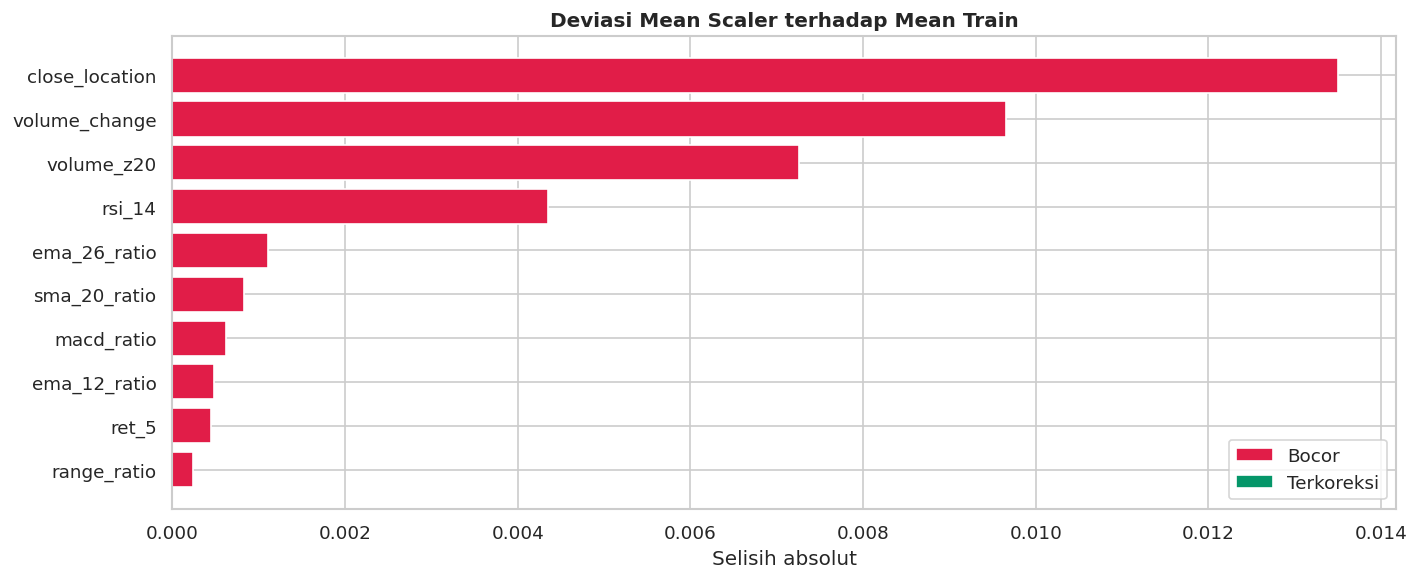

In [32]:
# TAHAP 11: audit statistik scaler
scaler_audit = pd.DataFrame(
    {
        "Fitur": FEATURE_COLUMNS,
        "Mean Train": X_train.mean().values,
        "Mean Seluruh Data": pd.concat([X_train, X_valid, X_test]).mean().values,
        "Mean Tersimpan Bocor": leaky_result["scaler"].mean_,
        "Mean Tersimpan Terkoreksi": clean_result["scaler"].mean_,
        "Std Tersimpan Bocor": leaky_result["scaler"].scale_,
        "Std Tersimpan Terkoreksi": clean_result["scaler"].scale_,
    }
)
scaler_audit["|Mean Bocor - Train|"] = (
    scaler_audit["Mean Tersimpan Bocor"] - scaler_audit["Mean Train"]
).abs()
scaler_audit["|Mean Benar - Train|"] = (
    scaler_audit["Mean Tersimpan Terkoreksi"] - scaler_audit["Mean Train"]
).abs()
scaler_audit = scaler_audit.sort_values("|Mean Bocor - Train|", ascending=False)

print("OUTPUT TAHAP 11: bukti statistik masa depan pada scaler bocor")
display(scaler_audit.head(12).round(6))

fig, ax = plt.subplots(figsize=(12, 5))
top = scaler_audit.head(10).sort_values("|Mean Bocor - Train|")
ax.barh(top["Fitur"], top["|Mean Bocor - Train|"], color=COLORS["Bocor"], label="Bocor")
ax.barh(top["Fitur"], top["|Mean Benar - Train|"], color=COLORS["Terkoreksi"], label="Terkoreksi")
ax.set_title("Deviasi Mean Scaler terhadap Mean Train")
ax.set_xlabel("Selisih absolut")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "09_audit_statistik_scaler.png", dpi=200, bbox_inches="tight")
plt.show()

OUTPUT TAHAP 12: diagnostik ekonomi, bukan rekomendasi investasi


,Pipeline,Return Kumulatif Bersih,Return Tahunan,Sharpe,Maximum Drawdown,Turnover Total,Biaya Total
0,Bocor,-62.26%,-33.63%,-2.403,-63.98%,91.0,9.10%
1,Terkoreksi,-61.73%,-33.24%,-2.364,-63.48%,89.0,8.90%


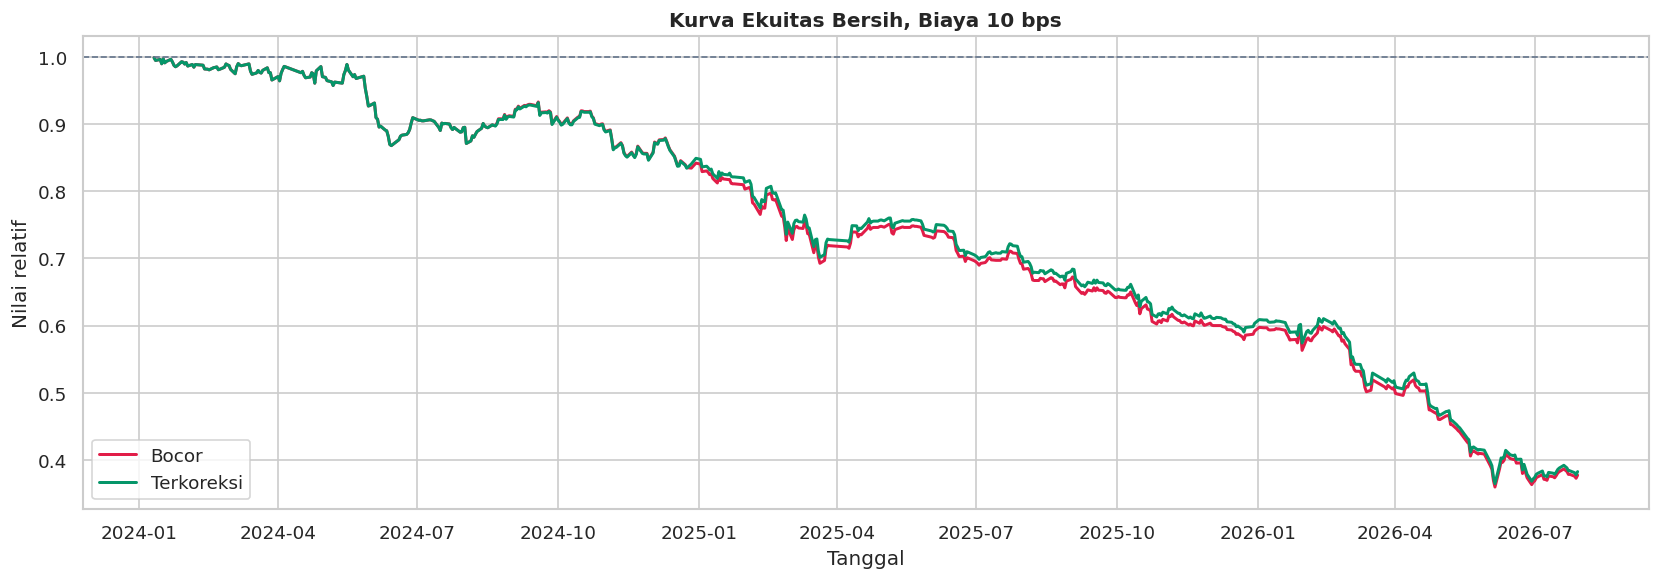

In [33]:
# TAHAP 12: evaluasi ekonomi sederhana dengan execution lag dan biaya
def financial_diagnostics(pred, returns, label):
    position = pd.Series(pred, index=returns.index, dtype=float)
    turnover = position.diff().abs().fillna(position.abs())
    cost = turnover * (TRANSACTION_COST_BPS / 10_000)
    gross = position * returns
    net = gross - cost
    equity = (1 + net).cumprod()
    periods = max(len(net), 1)
    annual_return = equity.iloc[-1] ** (252 / periods) - 1
    annual_vol = net.std(ddof=1) * np.sqrt(252)
    sharpe = (net.mean() * 252) / annual_vol if annual_vol > 0 else np.nan
    drawdown = equity / equity.cummax() - 1
    return {
        "Pipeline": label,
        "Return Kumulatif Bersih": equity.iloc[-1] - 1,
        "Return Tahunan": annual_return,
        "Sharpe": sharpe,
        "Maximum Drawdown": drawdown.min(),
        "Turnover Total": turnover.sum(),
        "Biaya Total": cost.sum(),
    }, equity


fin_leaky, equity_leaky = financial_diagnostics(
    leaky_result["test_pred"], test_df["NextReturn"], "Bocor"
)
fin_clean, equity_clean = financial_diagnostics(
    clean_result["test_pred"], test_df["NextReturn"], "Terkoreksi"
)
financial_table = pd.DataFrame([fin_leaky, fin_clean])

print("OUTPUT TAHAP 12: diagnostik ekonomi, bukan rekomendasi investasi")
financial_display = financial_table.copy()
for column in ["Return Kumulatif Bersih", "Return Tahunan", "Maximum Drawdown", "Biaya Total"]:
    financial_display[column] = financial_display[column].map(lambda x: f"{x:.2%}")
financial_display["Sharpe"] = financial_display["Sharpe"].map(lambda x: f"{x:.3f}")
financial_display["Turnover Total"] = financial_display["Turnover Total"].map(lambda x: f"{x:.1f}")
display(financial_display)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(equity_leaky.index, equity_leaky, color=COLORS["Bocor"], label="Bocor", lw=1.8)
ax.plot(equity_clean.index, equity_clean, color=COLORS["Terkoreksi"], label="Terkoreksi", lw=1.8)
ax.axhline(1.0, color="#64748B", linestyle="--", linewidth=1)
ax.set_title(f"Kurva Ekuitas Bersih, Biaya {TRANSACTION_COST_BPS} bps")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Nilai relatif")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "10_kurva_ekuitas.png", dpi=200, bbox_inches="tight")
plt.show()

OUTPUT TAHAP 13: rolling-forward validation


,Fold,Train Awal,Train Akhir,Validation Awal,Validation Akhir,Train Rows,Validation Rows,Scaler Fit Rows,Balanced Accuracy,F1,ROC-AUC
0,1,2010-02-01,2012-10-30,2012-11-01,2015-08-19,679,678,679,0.5134,0.6124,0.5131
1,2,2010-02-01,2015-08-18,2015-08-20,2018-05-31,1357,678,1357,0.5202,0.5641,0.5295
2,3,2010-02-01,2018-05-30,2018-06-04,2021-03-29,2035,678,2035,0.4919,0.4993,0.5084
3,4,2010-02-01,2021-03-26,2021-03-30,2024-01-09,2713,678,2713,0.5415,0.5658,0.5597


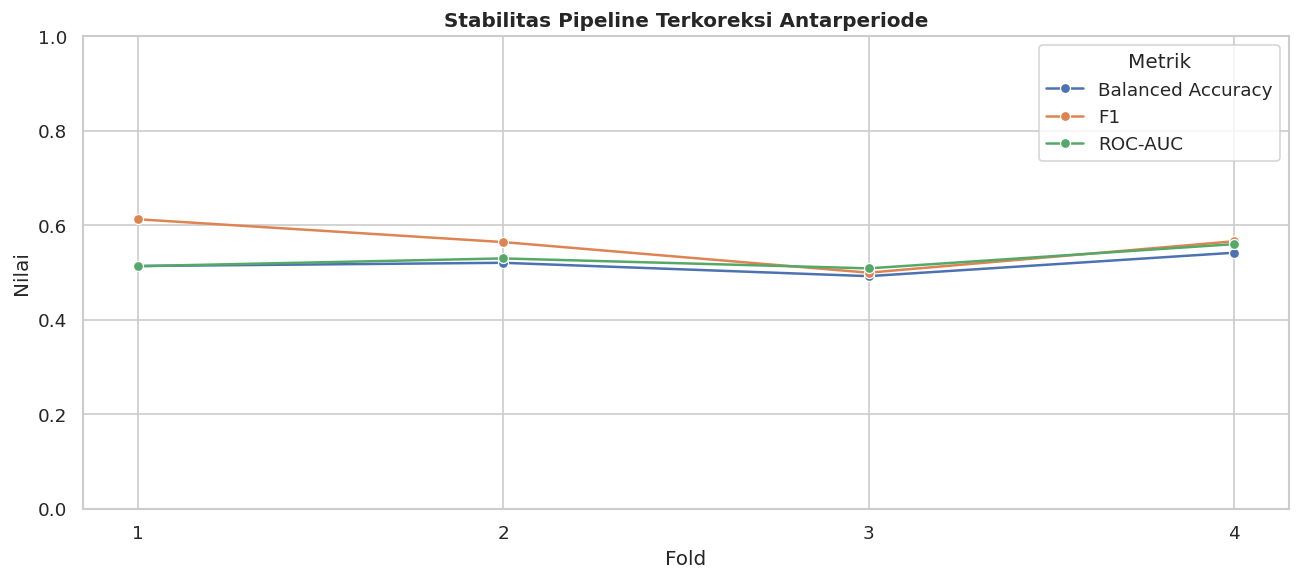

In [34]:
# TAHAP 13: rolling-forward cross-validation pada pipeline terkoreksi
development = pd.concat([train_df, valid_df], axis=0)
X_dev = development[FEATURE_COLUMNS]
y_dev = development["Target"]

tscv = TimeSeriesSplit(n_splits=4, gap=1)
fold_records = []
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_dev), start=1):
    X_fold_train = X_dev.iloc[train_idx]
    y_fold_train = y_dev.iloc[train_idx]
    X_fold_val = X_dev.iloc[val_idx]
    y_fold_val = y_dev.iloc[val_idx]

    fold_scaler = StandardScaler()
    Xft = fold_scaler.fit_transform(X_fold_train)
    Xfv = fold_scaler.transform(X_fold_val)
    fold_model = SVC(
        C=1.0, kernel="rbf", gamma="scale",
        class_weight="balanced", random_state=RANDOM_STATE
    )
    fold_model.fit(Xft, y_fold_train)
    fold_scores = fold_model.decision_function(Xfv)
    fold_pred = (fold_scores >= 0).astype(int)
    fold_records.append(
        {
            "Fold": fold,
            "Train Awal": X_fold_train.index.min(),
            "Train Akhir": X_fold_train.index.max(),
            "Validation Awal": X_fold_val.index.min(),
            "Validation Akhir": X_fold_val.index.max(),
            "Train Rows": len(X_fold_train),
            "Validation Rows": len(X_fold_val),
            "Scaler Fit Rows": fold_scaler.n_samples_seen_,
            "Balanced Accuracy": balanced_accuracy_score(y_fold_val, fold_pred),
            "F1": f1_score(y_fold_val, fold_pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_fold_val, fold_scores),
        }
    )

walk_forward_table = pd.DataFrame(fold_records)
print("OUTPUT TAHAP 13: rolling-forward validation")
display(walk_forward_table)

wf_plot = walk_forward_table.melt(
    id_vars="Fold", value_vars=["Balanced Accuracy", "F1", "ROC-AUC"],
    var_name="Metrik", value_name="Nilai"
)
fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=wf_plot, x="Fold", y="Nilai", hue="Metrik", marker="o", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Stabilitas Pipeline Terkoreksi Antarperiode")
ax.set_xticks(walk_forward_table["Fold"])
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "11_rolling_forward.png", dpi=200, bbox_inches="tight")
plt.show()

In [35]:
# TAHAP 14: tes otomatis integritas pipeline
train_mean = X_train.mean().values
checks = [
    ("Tanggal data meningkat", ihsg.index.is_monotonic_increasing, "Data tidak boleh diacak"),
    ("Tanggal data unik", not ihsg.index.duplicated().any(), "Satu tanggal satu observasi"),
    ("Target lebih baru dari fitur", bool((model_data["TargetDate"] > model_data.index).all()), "Cegah off-by-one"),
    ("Target tidak ada di fitur", "Target" not in FEATURE_COLUMNS, "Cegah target leakage langsung"),
    ("NextReturn tidak ada di fitur", "NextReturn" not in FEATURE_COLUMNS, "Cegah future return leakage"),
    ("Train sebelum validation", train_df.index.max() < valid_df.index.min(), "Pemisahan kronologis"),
    ("Validation sebelum test", valid_df.index.max() < test_df.index.min(), "Pemisahan kronologis"),
    ("Target train sebelum validation", train_df["TargetDate"].max() < valid_df.index.min(), "Purge batas train"),
    ("Target validation sebelum test", valid_df["TargetDate"].max() < test_df.index.min(), "Purge batas validation"),
    ("Scaler benar hanya melihat train", clean_result["scaler"].n_samples_seen_ == len(X_train), "Fit scope"),
    ("Mean scaler benar sama dengan train", np.allclose(clean_result["scaler"].mean_, train_mean), "Statistik train"),
    ("Scaler bocor melihat data tambahan", leaky_result["scaler"].n_samples_seen_ > len(X_train), "Bukti eksperimen bocor"),
    ("Fitur train bernilai finite", np.isfinite(X_train.to_numpy()).all(), "Cegah NaN dan inf"),
    ("Kedua kelas tersedia pada train", y_train.nunique() == 2, "Model klasifikasi valid"),
    ("Sumber sesuai IHSG atau diberi label", source_valid_for_research or DATA_SOURCE.startswith("SYNTHETIC"), "Transparansi sumber"),
]
automatic_checks = pd.DataFrame(checks, columns=["Pemeriksaan", "Hasil", "Tujuan"])
automatic_checks["Status"] = np.where(automatic_checks["Hasil"], "LULUS", "GAGAL")

print("OUTPUT TAHAP 14: pemeriksaan otomatis")
display(automatic_checks)
if (automatic_checks["Status"] == "GAGAL").any():
    failed = automatic_checks.loc[automatic_checks["Status"] == "GAGAL", "Pemeriksaan"].tolist()
    raise AssertionError(f"Audit logika gagal: {failed}")

OUTPUT TAHAP 14: pemeriksaan otomatis


,Pemeriksaan,Hasil,Tujuan,Status
0,Tanggal data meningkat,True,Data tidak boleh diacak,LULUS
1,Tanggal data unik,True,Satu tanggal satu observasi,LULUS
2,Target lebih baru dari fitur,True,Cegah off-by-one,LULUS
3,Target tidak ada di fitur,True,Cegah target leakage langsung,LULUS
4,NextReturn tidak ada di fitur,True,Cegah future return leakage,LULUS
5,Train sebelum validation,True,Pemisahan kronologis,LULUS
6,Validation sebelum test,True,Pemisahan kronologis,LULUS
7,Target train sebelum validation,True,Purge batas train,LULUS
8,Target validation sebelum test,True,Purge batas validation,LULUS
9,Scaler benar hanya melihat train,True,Fit scope,LULUS


In [36]:
# TAHAP 15: tabel audit leakage dan bug logika
metric_delta = {
    row: float(comparison.loc[row, "Selisih Terkoreksi - Bocor"])
    for row in comparison.index
}
audit_table = pd.DataFrame(
    [
        (
            "Scaling sebelum split",
            "scaler.fit_transform(X_all)",
            "Mean dan standar deviasi validation serta test",
            "Tinggi",
            "Fit pada X_train, transform kelompok lain",
            "Terverifikasi",
        ),
        (
            "Random shuffle",
            "Tidak ditemukan pada kode final",
            "Urutan masa depan dapat masuk ke train",
            "Tinggi",
            "Split berdasarkan tanggal",
            "Terverifikasi",
        ),
        (
            "Target terintip fitur",
            "Target dan NextReturn tidak masuk FEATURE_COLUMNS",
            "Label atau return t+1",
            "Kritis",
            "Daftar fitur eksplisit dan assertion",
            "Terverifikasi",
        ),
        (
            "Target melewati batas split",
            "TargetDate diperiksa terhadap batas periode",
            "Harga awal periode berikutnya",
            "Tinggi",
            "Purge observasi batas",
            "Terverifikasi",
        ),
        (
            "Scaling di luar fold",
            "Setiap fold membuat StandardScaler baru",
            "Statistik fold validation",
            "Tinggi",
            "Fit scaler pada fold train aktif",
            "Terverifikasi",
        ),
        (
            "Threshold memakai test",
            "Threshold dipilih dari validation_scores",
            "Distribusi label data uji",
            "Tinggi",
            "Kunci test sampai threshold tetap",
            "Terverifikasi",
        ),
        (
            "Akurasi menutupi kelas timpang",
            "Accuracy dibandingkan dengan balanced accuracy dan F1",
            "Proporsi kelas mayoritas",
            "Sedang",
            "Laporkan beberapa metrik dan confusion matrix",
            "Terverifikasi",
        ),
        (
            "Biaya transaksi diabaikan",
            f"Biaya {TRANSACTION_COST_BPS} bps diterapkan saat posisi berubah",
            "Dampak turnover pada return",
            "Sedang",
            "Laporkan return bersih dan drawdown",
            "Terverifikasi",
        ),
        (
            "Sumber sintetis disalahartikan",
            DATA_SOURCE,
            "Data buatan dapat dianggap sebagai IHSG nyata",
            "Kritis",
            "Blokir kesimpulan IHSG jika sumber fallback",
            "Terverifikasi" if source_valid_for_research else "Perlu CSV/Internet",
        ),
    ],
    columns=[
        "Temuan", "Bukti", "Informasi Terpapar atau Dampak", "Risiko",
        "Perbaikan", "Status Verifikasi"
    ],
)
print("OUTPUT TAHAP 15: tabel audit integritas")
display(audit_table)

delta_display = pd.DataFrame(
    {"Metrik": list(metric_delta.keys()), "Perubahan Setelah Koreksi": list(metric_delta.values())}
)
delta_display["Perubahan Setelah Koreksi"] = delta_display[
    "Perubahan Setelah Koreksi"
].map(lambda x: f"{x:+.4f}")
display(delta_display)

OUTPUT TAHAP 15: tabel audit integritas


,Temuan,Bukti,Informasi Terpapar atau Dampak,Risiko,Perbaikan,Status Verifikasi
0,Scaling sebelum split,scaler.fit_transform(X_all),Mean dan standar deviasi validation serta test,Tinggi,"Fit pada X_train, transform kelompok lain",Terverifikasi
1,Random shuffle,Tidak ditemukan pada kode final,Urutan masa depan dapat masuk ke train,Tinggi,Split berdasarkan tanggal,Terverifikasi
2,Target terintip fitur,Target dan NextReturn tidak masuk FEATURE_COLUMNS,Label atau return t+1,Kritis,Daftar fitur eksplisit dan assertion,Terverifikasi
3,Target melewati batas split,TargetDate diperiksa terhadap batas periode,Harga awal periode berikutnya,Tinggi,Purge observasi batas,Terverifikasi
4,Scaling di luar fold,Setiap fold membuat StandardScaler baru,Statistik fold validation,Tinggi,Fit scaler pada fold train aktif,Terverifikasi
5,Threshold memakai test,Threshold dipilih dari validation_scores,Distribusi label data uji,Tinggi,Kunci test sampai threshold tetap,Terverifikasi
6,Akurasi menutupi kelas timpang,Accuracy dibandingkan dengan balanced accuracy dan F1,Proporsi kelas mayoritas,Sedang,Laporkan beberapa metrik dan confusion matrix,Terverifikasi
7,Biaya transaksi diabaikan,Biaya 10 bps diterapkan saat posisi berubah,Dampak turnover pada return,Sedang,Laporkan return bersih dan drawdown,Terverifikasi
8,Sumber sintetis disalahartikan,Yahoo Finance: ^JKSE,Data buatan dapat dianggap sebagai IHSG nyata,Kritis,Blokir kesimpulan IHSG jika sumber fallback,Terverifikasi


,Metrik,Perubahan Setelah Koreksi
0,Accuracy,+0.0050
1,Balanced Accuracy,+0.0062
2,Precision,+0.0034
3,Recall,+0.0185
4,F1,+0.0072
5,ROC-AUC,+0.0007


In [37]:
# TAHAP 16: analisis kritis berbasis hasil aktual
f1_leaky = float(metric_table.loc[metric_table["Pipeline"] == "Bocor", "F1"].iloc[0])
f1_clean = float(metric_table.loc[metric_table["Pipeline"] == "Terkoreksi", "F1"].iloc[0])
auc_clean = float(metric_table.loc[metric_table["Pipeline"] == "Terkoreksi", "ROC-AUC"].iloc[0])
acc_delta = acc_clean - acc_leaky

if not source_valid_for_research:
    conclusion_status = (
        "Notebook berjalan memakai data sintetis. Hasil hanya memverifikasi kode. "
        "Unggah CSV IHSG atau aktifkan Internet Kaggle sebelum menarik kesimpulan empiris."
    )
elif max(acc_leaky, acc_clean) >= 0.99:
    conclusion_status = (
        "Skor 99% muncul. Scaling leakage belum cukup menjadi penjelasan tunggal. "
        "Periksa target di fitur, random split, duplikasi window, target shift, dan tuning pada test."
    )
elif abs(acc_delta) < 0.01:
    conclusion_status = (
        "Perubahan akurasi kecil, tetapi jalur bocor tetap tidak sah. "
        "Kebocoran dapat mengubah representasi data tanpa selalu mengubah banyak prediksi kelas."
    )
else:
    conclusion_status = (
        "Koreksi scaling mengubah metrik secara material. "
        "Metrik terkoreksi harus dipakai sebagai estimasi kinerja yang lebih jujur."
    )

critical_analysis = pd.DataFrame(
    [
        ("Akurasi bocor", f"{acc_leaky:.4f}", "Tidak layak menjadi klaim final"),
        ("Akurasi terkoreksi", f"{acc_clean:.4f}", "Kinerja pada test setelah fit scaler train"),
        ("Selisih akurasi", f"{acc_delta:+.4f}", "Terkoreksi dikurangi bocor"),
        ("F1 bocor", f"{f1_leaky:.4f}", "Sensitif pada kelas positif"),
        ("F1 terkoreksi", f"{f1_clean:.4f}", "F1 yang dapat dilaporkan"),
        ("ROC-AUC terkoreksi", f"{auc_clean:.4f}", "Kemampuan pemeringkatan skor"),
        ("Kesimpulan audit", conclusion_status, "Keputusan berbasis bukti"),
    ],
    columns=["Butir", "Hasil", "Makna"],
)
print("OUTPUT TAHAP 16: analisis logis dan kritis")
display(critical_analysis)

print("\nNARASI KESIMPULAN\n")
print(
    f"Jalur bocor menghasilkan akurasi {acc_leaky:.4f}, sedangkan jalur "
    f"terkoreksi menghasilkan {acc_clean:.4f}. Selisihnya {acc_delta:+.4f}. "
    f"F1 berubah dari {f1_leaky:.4f} menjadi {f1_clean:.4f}. "
    + conclusion_status
)

OUTPUT TAHAP 16: analisis logis dan kritis


,Butir,Hasil,Makna
0,Akurasi bocor,0.4641,Tidak layak menjadi klaim final
1,Akurasi terkoreksi,0.4691,Kinerja pada test setelah fit scaler train
2,Selisih akurasi,+0.0050,Terkoreksi dikurangi bocor
3,F1 bocor,0.6002,Sensitif pada kelas positif
4,F1 terkoreksi,0.6074,F1 yang dapat dilaporkan
5,ROC-AUC terkoreksi,0.5240,Kemampuan pemeringkatan skor
6,Kesimpulan audit,"Perubahan akurasi kecil, tetapi jalur bocor tetap tidak sah. Kebocoran dapat mengubah representasi data tanpa selalu mengubah banyak pre...",Keputusan berbasis bukti



NARASI KESIMPULAN

Jalur bocor menghasilkan akurasi 0.4641, sedangkan jalur terkoreksi menghasilkan 0.4691. Selisihnya +0.0050. F1 berubah dari 0.6002 menjadi 0.6074. Perubahan akurasi kecil, tetapi jalur bocor tetap tidak sah. Kebocoran dapat mengubah representasi data tanpa selalu mengubah banyak prediksi kelas.


In [38]:
# TAHAP 17: ekspor seluruh keluaran
predictions_export = prediction_preview.copy()
predictions_export.index.name = "Date"

exports = {
    "kualitas_data.csv": quality_report,
    "ringkasan_split.csv": split_summary,
    "metrik_model.csv": metric_table,
    "perbandingan_metrik.csv": comparison.reset_index(names="Metrik"),
    "audit_scaler.csv": scaler_audit,
    "diagnostik_ekonomi.csv": financial_table,
    "rolling_forward.csv": walk_forward_table,
    "pemeriksaan_otomatis.csv": automatic_checks,
    "tabel_audit_leakage.csv": audit_table,
    "prediksi_test.csv": predictions_export.reset_index(),
}
for filename, table in exports.items():
    table.to_csv(OUTPUT_DIR / filename, index=False)

report_text = f'''LAPORAN RINGKAS AUDIT PIPELINE IHSG
Sumber data: {DATA_SOURCE}
Periode: {ihsg.index.min().date()} sampai {ihsg.index.max().date()}
Akurasi bocor: {acc_leaky:.6f}
Akurasi terkoreksi: {acc_clean:.6f}
Selisih: {acc_delta:+.6f}
F1 bocor: {f1_leaky:.6f}
F1 terkoreksi: {f1_clean:.6f}
ROC-AUC terkoreksi: {auc_clean:.6f}
Kesimpulan: {conclusion_status}
'''
(OUTPUT_DIR / "laporan_ringkas.txt").write_text(report_text, encoding="utf-8")

manifest = pd.DataFrame(
    [
        {
            "File": p.name,
            "Ukuran KB": round(p.stat().st_size / 1024, 1),
            "Lokasi": str(p),
        }
        for p in sorted(OUTPUT_DIR.iterdir())
        if p.is_file()
    ]
)
print("OUTPUT TAHAP 17: manifest hasil")
display(manifest)
print(f"Seluruh hasil tersimpan di: {OUTPUT_DIR}")

OUTPUT TAHAP 17: manifest hasil


,File,Ukuran KB,Lokasi
0,01_harga_penutupan.png,130.9000,/kaggle/working/ihsg_leakage_audit/01_harga_penutupan.png
1,02_kelengkapan_bulanan.png,45.5000,/kaggle/working/ihsg_leakage_audit/02_kelengkapan_bulanan.png
2,03_korelasi_fitur.png,129.5000,/kaggle/working/ihsg_leakage_audit/03_korelasi_fitur.png
3,04_alignment_timeline.png,47.5000,/kaggle/working/ihsg_leakage_audit/04_alignment_timeline.png
4,05_split_kronologis.png,52.9000,/kaggle/working/ihsg_leakage_audit/05_split_kronologis.png
5,06_pipeline_sebelum_sesudah.png,126.2000,/kaggle/working/ihsg_leakage_audit/06_pipeline_sebelum_sesudah.png
6,07_perbandingan_metrik.png,57.2000,/kaggle/working/ihsg_leakage_audit/07_perbandingan_metrik.png
7,08_confusion_roc.png,138.2000,/kaggle/working/ihsg_leakage_audit/08_confusion_roc.png
8,09_audit_statistik_scaler.png,82.0000,/kaggle/working/ihsg_leakage_audit/09_audit_statistik_scaler.png
9,10_kurva_ekuitas.png,147.5000,/kaggle/working/ihsg_leakage_audit/10_kurva_ekuitas.png


Seluruh hasil tersimpan di: /kaggle/working/ihsg_leakage_audit


## C. Pedoman Penafsiran

**Penurunan skor tidak otomatis menandakan model memburuk.** Jalur
terkoreksi membatasi informasi sesuai kondisi nyata saat prediksi dibuat.
Skor ini lebih layak dilaporkan.

**Selisih kecil tidak menghapus masalah metodologis.** Statistik data uji
tetap masuk ke representasi data latih pada jalur bocor. Dampak terhadap
prediksi dapat kecil pada satu periode dan besar pada periode lain.

**Skor 99% memerlukan audit lanjutan.** Periksa fitur yang memuat target,
pergeseran indeks yang salah, pengacakan deret waktu, jendela yang
tumpang tindih antarkelompok, duplikasi observasi, ketimpangan kelas,
serta pemilihan model berulang memakai data uji.

**Sumber data harus dibaca sebelum menyimpulkan.** Jika notebook memakai
`SYNTHETIC_TEST_ONLY` atau `SYNTHETIC_FALLBACK_NOT_FOR_CONCLUSION`, hasil
hanya membuktikan bahwa program berjalan. Kesimpulan empiris IHSG baru
sah setelah CSV IHSG dimasukkan atau unduhan `^JKSE` berhasil.